# **03 - Machine Learning**

## Objectives

- Prepare the cleaned retail data for machine learning.
- Define an appropriate machine learning problem based on the exploratory analysis.
- Select and justify a suitable algorithm.
- Train and evaluate the model using appropriate performance metrics.
- Interpret the model results and assess its usefulness for the business.
- Identify limitations and potential improvements.

## Inputs

- Cleaned Online Retail Transaction dataset produced during the ETL process and explored during EDA.

## Outputs

- A trained and evaluated machine learning model.
- Model performance metrics and visualisations.
- Interpretation of the model results and their business relevance.

## Additional Comments

- The modelling approach will be selected based on the business problem and characteristics identified during exploratory analysis.

---

# Change working directory

In [1]:
import os

current_dir = os.getcwd()
print("Current directory:", current_dir)

if os.path.basename(current_dir) == "jupyter_notebooks":
    os.chdir(os.path.dirname(current_dir))
elif os.path.basename(current_dir) == "vscode-projects":
    os.chdir("Online Retail Transaction Analysis")

current_dir = os.getcwd()
print("Working directory set to:", current_dir)

Current directory: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis/jupyter_notebooks
Working directory set to: /Users/sahraosman/Documents/vscode-projects/Online Retail Transaction Analysis


---

# Section 1 -  Import libraries

Here I will be importing the libraries that I will be using in this notebook.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

---

# Section 2 - Load the dataset

The cleaned Online Retail dataset produced during the ETL stage will be loaded for the machine learning analysis. I will first inspect the dataset to confirm that it has loaded correctly before preparing the data for modelling.

In [3]:
df = pd.read_csv(
    "outputs/online_retail_cleaned.csv",
    dtype={"InvoiceNo": str},
    parse_dates=["InvoiceDate"],
)

In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [5]:
df.shape

(524878, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    524878 non-null  object        
 1   StockCode    524878 non-null  object        
 2   Description  524878 non-null  object        
 3   Quantity     524878 non-null  int64         
 4   InvoiceDate  524878 non-null  datetime64[ns]
 5   UnitPrice    524878 non-null  float64       
 6   CustomerID   524878 non-null  int64         
 7   Country      524878 non-null  object        
 8   Revenue      524878 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 36.0+ MB


The cleaned dataset contains 524,878 rows and 9 columns, with no missing values. The data types have also loaded as expected, including `InvoiceDate` as a datetime.

This confirms that the cleaned dataset has loaded correctly and is ready to be prepared for the machine learning analysis.

---

# Section 3 - Define the Machine Learning Problem

The exploratory analysis identified differences in customer purchasing behaviour. Customers varied in how frequently they made purchases and in the total revenue they generated. The analysis also showed that high average transaction values could sometimes be influenced by a small number of unusually large purchases.

Based on these findings, customer segmentation was selected as the machine learning problem. The aim is to identify groups of customers with similar purchasing behaviours using Recency, Frequency and Monetary (RFM) measures.

As the dataset does not contain predefined customer segment labels, this is an unsupervised machine learning problem. K-Means clustering will be used to group customers based on similarities in their RFM characteristics.

K-Means was selected because it is suitable for grouping numerical observations based on similarity, which aligns with the numerical RFM features used in this analysis. It also produces clearly defined clusters that can be profiled and interpreted as customer segments. As K-Means is distance-based, the RFM features will be transformed and standardised before modelling to reduce the influence of skewness and differences in scale.

---

# Section 4 - Create RFM Features

To prepare the data for customer segmentation, Recency, Frequency and Monetary (RFM) features will be created for each customer.

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of unique transactions made by the customer.
- **Monetary:** Total revenue generated by the customer.

A reference date one day after the latest transaction in the dataset will be used to calculate Recency. This provides a consistent point from which the number of days since each customer's most recent purchase can be measured and ensures that customers who purchased on the final date have a Recency value greater than zero.

In [7]:
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

reference_date

Timestamp('2011-12-10 12:50:00')

The dataset will now be grouped by `CustomerID` to calculate each customer's Recency, Frequency and Monetary values.

In [8]:
customer_last_purchase = df.groupby("CustomerID")["InvoiceDate"].max().reset_index()
customer_last_purchase

,CustomerID,InvoiceDate
0,12346,2011-01-18 10:01:00
1,12347,2011-12-07 15:52:00
2,12348,2011-09-25 13:13:00
3,12349,2011-11-21 09:51:00
4,12350,2011-02-02 16:01:00
...,...,...
4333,18280,2011-03-07 09:52:00
4334,18281,2011-06-12 10:53:00
4335,18282,2011-12-02 11:43:00
4336,18283,2011-12-06 12:02:00


In [9]:
customer_last_purchase["Recency"] = (
    reference_date - customer_last_purchase["InvoiceDate"]
).dt.days
customer_last_purchase

,CustomerID,InvoiceDate,Recency
0,12346,2011-01-18 10:01:00,326
1,12347,2011-12-07 15:52:00,2
2,12348,2011-09-25 13:13:00,75
3,12349,2011-11-21 09:51:00,19
4,12350,2011-02-02 16:01:00,310
...,...,...,...
4333,18280,2011-03-07 09:52:00,278
4334,18281,2011-06-12 10:53:00,181
4335,18282,2011-12-02 11:43:00,8
4336,18283,2011-12-06 12:02:00,4


Frequency is calculated using the number of unique `InvoiceNo` values rather than the number of rows, as a single transaction can contain multiple product lines.

In [10]:
customer_frequency = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index()
customer_frequency.rename(columns={"InvoiceNo": "Frequency"}, inplace=True)
customer_frequency

,CustomerID,Frequency
0,12346,1
1,12347,7
2,12348,4
3,12349,1
4,12350,1
...,...,...
4333,18280,1
4334,18281,1
4335,18282,2
4336,18283,16


In [11]:
customer_monetary = df.groupby("CustomerID")["Revenue"].sum().reset_index()
customer_monetary.rename(columns={"Revenue": "Monetary"}, inplace=True)
customer_monetary

,CustomerID,Monetary
0,12346,77183.60
1,12347,4310.00
2,12348,1797.24
3,12349,1757.55
4,12350,334.40
...,...,...
4333,18280,180.60
4334,18281,80.82
4335,18282,178.05
4336,18283,2045.53


The three RFM measures were merged using `CustomerID`, creating one record per customer. `InvoiceDate` was then removed because the relevant time-based information is represented by the Recency feature.

In [12]:
rfm = customer_last_purchase.merge(customer_frequency, on="CustomerID").merge(
    customer_monetary, on="CustomerID"
)

In [13]:
rfm.head()

,CustomerID,InvoiceDate,Recency,Frequency,Monetary
0,12346,2011-01-18 10:01:00,326,1,77183.60
1,12347,2011-12-07 15:52:00,2,7,4310.00
2,12348,2011-09-25 13:13:00,75,4,1797.24
3,12349,2011-11-21 09:51:00,19,1,1757.55
4,12350,2011-02-02 16:01:00,310,1,334.40


In [14]:
rfm.shape

(4338, 5)

In [15]:
rfm = rfm.drop(columns=["InvoiceDate"])

In [16]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [17]:
rfm.shape

(4338, 4)

### Inspect RFM Features

Before preparing the features for clustering, their descriptive statistics and distributions will be examined to identify differences in scale, skewness and extreme values.

In [18]:
rfm[["Recency", "Frequency", "Monetary"]].describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4.338000e+03
mean,92.531581,4.601199,2.453230e+03
std,100.018092,22.974719,2.809629e+04
min,1.000000,1.000000,3.750000e+00
25%,18.000000,1.000000,3.064825e+02
50%,51.000000,2.000000,6.701350e+02
75%,142.000000,5.000000,1.660895e+03
max,374.000000,1430.000000,1.755389e+06


The descriptive statistics show that the RFM features have very different ranges, with particularly large maximum values for Frequency and Monetary. Their distributions will therefore be visualised to examine the extent of skewness and extreme values.

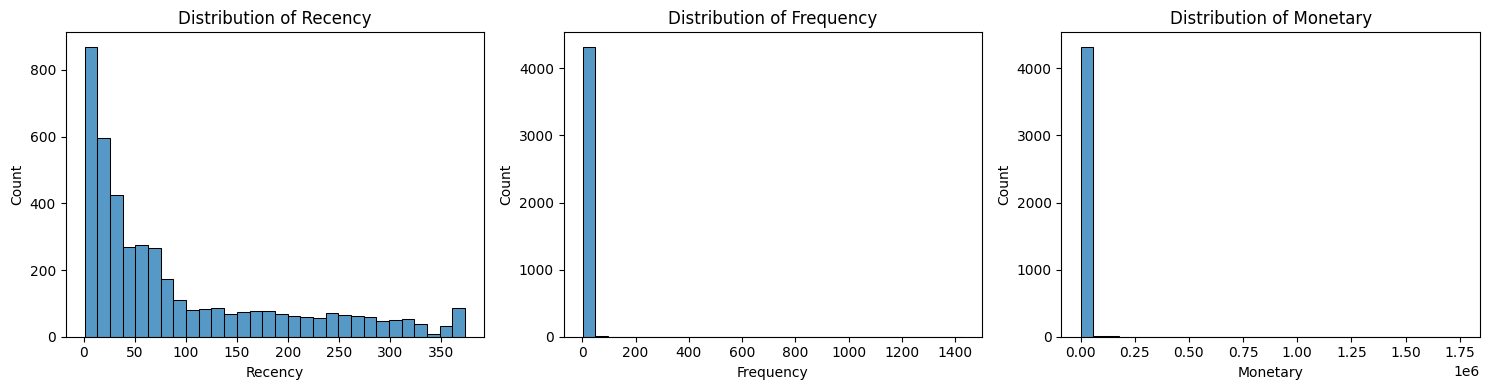

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Recency")

sns.histplot(rfm["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Frequency")

sns.histplot(rfm["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Distribution of Monetary")

plt.tight_layout()
plt.show()

In [20]:
frequency_99 = rfm["Frequency"].quantile(0.99)
monetary_99 = rfm["Monetary"].quantile(0.99)

print("Frequency 99th percentile:", frequency_99)
print("Monetary 99th percentile:", monetary_99)

Frequency 99th percentile: 30.0
Monetary 99th percentile: 20095.434800000054


Since the original Frequency and Monetary distributions are compressed by a small number of very large values, the lower 99% will be visualised separately to examine the main customer distribution more clearly. This filtering is only applied to the visualisation and does not remove customers from the modelling dataset.

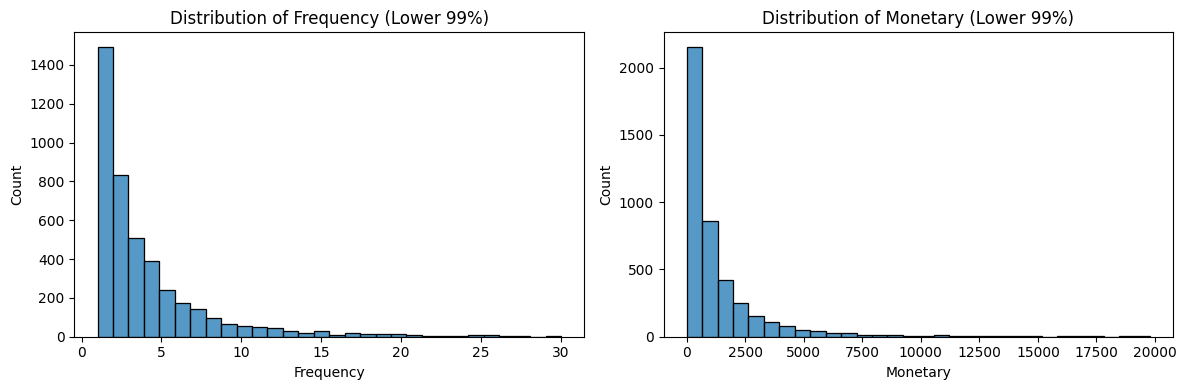

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(rfm[rfm["Frequency"] <= frequency_99]["Frequency"], bins=30, ax=axes[0])
axes[0].set_title("Distribution of Frequency (Lower 99%)")

sns.histplot(rfm[rfm["Monetary"] <= monetary_99]["Monetary"], bins=30, ax=axes[1])
axes[1].set_title("Distribution of Monetary (Lower 99%)")

plt.tight_layout()
plt.show()

The focused distributions show that Frequency and Monetary remain strongly right-skewed even when the upper 1% of values are excluded from the visualisation. Most customers make a small number of transactions and generate relatively low total revenue, while progressively fewer customers have higher Frequency and Monetary values.

The descriptive statistics also showed large differences in scale between the three RFM features. Therefore, the features will need to be prepared before applying K-Means clustering so that extreme values and differences in scale do not have too much influence on the model.

---

# Section 5 - Prepare RFM Features for Clustering

The RFM analysis showed that the features are right-skewed and measured on different scales. The features will therefore be transformed and standardised before clustering to reduce the influence of extreme values and ensure that no single feature dominates the distance calculations used by K-Means.

A separate modelling dataset is created using only the RFM features. `CustomerID` is excluded because it is an identifier rather than a measure of customer behaviour and should not influence the clustering.

In [22]:
rfm_model = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_model.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1797.24
3,19,1,1757.55
4,310,1,334.40


A log transformation is applied to reduce the strong right-skew and compress the influence of unusually large values identified during the RFM analysis. The original RFM dataset is retained so that the final clusters can later be interpreted using the original customer values.

In [23]:
rfm_log = np.log1p(rfm_model)

rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.494564
3,2.995732,0.693147,7.472245
4,5.739793,0.693147,5.815324


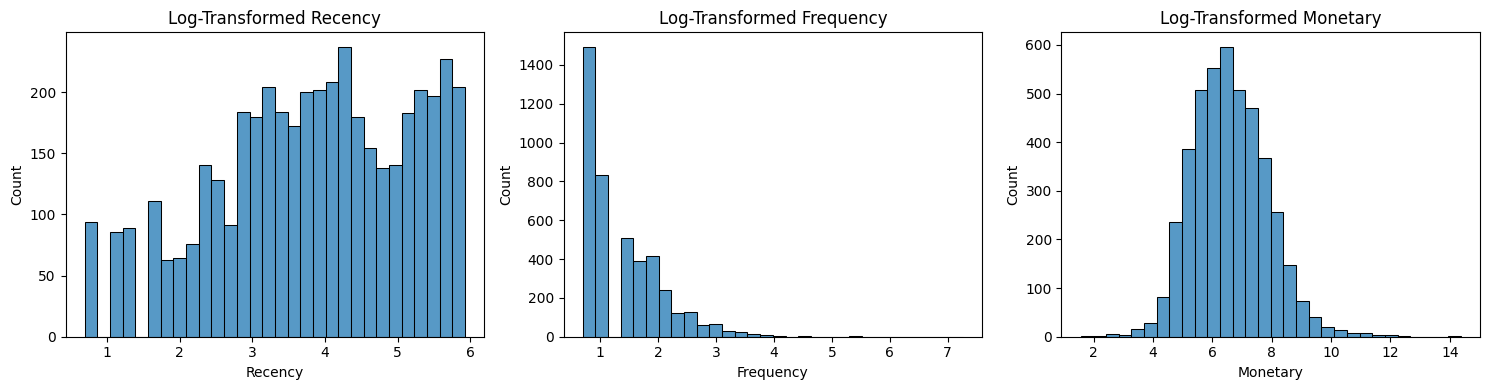

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(rfm_log["Recency"], bins=30, ax=axes[0])
axes[0].set_title("Log-Transformed Recency")

sns.histplot(rfm_log["Frequency"], bins=30, ax=axes[1])
axes[1].set_title("Log-Transformed Frequency")

sns.histplot(rfm_log["Monetary"], bins=30, ax=axes[2])
axes[2].set_title("Log-Transformed Monetary")

plt.tight_layout()
plt.show()

The log transformation reduced the effect of the large values within the RFM features. The improvement is particularly visible for Monetary, which now has a more balanced distribution compared with the original strongly right-skewed data.

Frequency remains right-skewed because many customers have only a small number of transactions, although the extreme values have been compressed considerably. The transformation also reduced the range of Recency values.

The transformed features will now be standardised before applying K-Means clustering.

### Standardise RFM Features

K-Means clustering is based on distances between observations, so differences in feature scale can affect the resulting clusters. The log-transformed RFM features will therefore be standardised so that each feature contributes more comparably to the distance calculations.

In [25]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled

array([[ 1.46153524, -0.94912762,  3.68999905],
       [-2.03709096,  1.06319382,  1.40721873],
       [ 0.37330018,  0.3809445 ,  0.71538012],
       ...,
       [-1.21778831, -0.36056133, -1.10995361],
       [-1.65613692,  2.15735621,  0.81771825],
       [-0.03429102,  0.0570331 ,  0.73280499]], shape=(4338, 3))

In [26]:
rfm_scaled = pd.DataFrame(rfm_scaled, columns=["Recency", "Frequency", "Monetary"])

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461535,-0.949128,3.689999
1,-2.037091,1.063194,1.407219
2,0.373300,0.380945,0.715380
3,-0.622292,-0.949128,0.697720
4,1.424122,-0.949128,-0.613319


The scaled values are converted back into a DataFrame using the original RFM feature names to make the transformed data easier to inspect. Summary statistics will then be checked to confirm that the standardisation has been applied successfully.

In [27]:
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,4.291429e-16,-4.750055e-17,-1.048288e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.339471e+00,-9.491276e-01,-3.981812e+00
25%,-6.605447e-01,-9.491276e-01,-6.820827e-01
50%,9.029147e-02,-3.605613e-01,-6.447286e-02
75%,8.447044e-01,6.455994e-01,6.529901e-01
max,1.563679e+00,8.592101e+00,6.162059e+00


The summary statistics confirm that the standardisation was successful. Each RFM feature now has a mean approximately equal to 0 and a standard deviation approximately equal to 1.

The transformed features are therefore on comparable scales and are ready to be used for K-Means clustering.

---

# Section 6 - Select the Optimal Number of Clusters

Before training the final K-Means model, the number of clusters needs to be selected. Multiple values of K will be tested using the Elbow Method and Silhouette Score to identify a suitable number of customer segments.

### Elbow Method

The Elbow Method will be used to examine how the within-cluster variation changes as the number of clusters increases. K-Means models will be fitted using values of K from 2 to 10, and the inertia for each model will be recorded.

Lower inertia indicates that customers are closer to their assigned cluster centroids. However, inertia naturally decreases as more clusters are added, so the aim is to identify the point where adding further clusters produces smaller improvements.

In [28]:
k_values = range(2, 11)
inertia = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
inertia

[6518.439805551472,
 4904.804684019723,
 3976.9653714622755,
 3327.7118819834086,
 2889.9272465623385,
 2585.751038514074,
 2367.592746230647,
 2193.12684883904,
 2024.7234405335241]

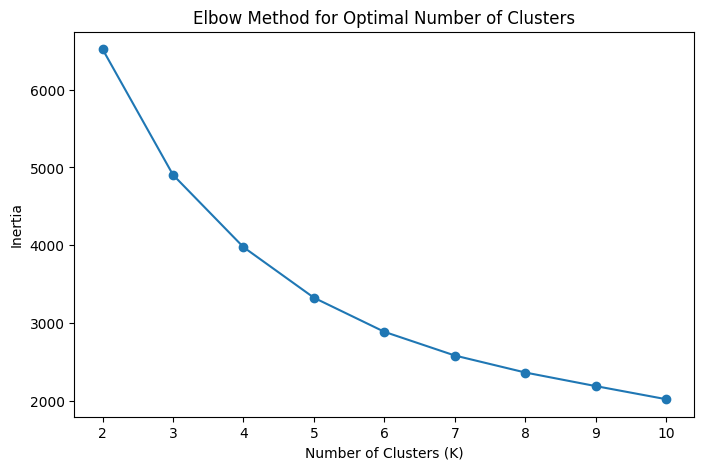

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal Number of Clusters")
plt.xticks(k_values)

plt.show()

The Elbow curve shows a substantial decrease in inertia as the number of clusters increases from 2 to around 4–5. Beyond this point, the reduction in inertia becomes more gradual, suggesting diminishing improvements from adding further clusters.

The elbow is not completely distinct, although approximately 4–5 clusters appear to be reasonable candidates. The Silhouette Score will therefore also be evaluated before selecting the final number of clusters.

### Silhouette Score

The Silhouette Score will also be used to evaluate the different values of K. This metric considers both how closely observations are grouped within their own cluster and how well separated they are from other clusters.

Silhouette Scores range from -1 to 1, with higher values indicating more compact and well-separated clusters.

In [30]:
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    cluster_labels = kmeans.fit_predict(rfm_scaled)

    score = silhouette_score(rfm_scaled, cluster_labels)
    silhouette_scores.append(score)

silhouette_scores

[0.4326971147783671,
 0.3364288398143438,
 0.3373167884412268,
 0.3186144737689767,
 0.3123312288986276,
 0.3027316278734961,
 0.30073127208667577,
 0.29484520961743904,
 0.2784505586763215]

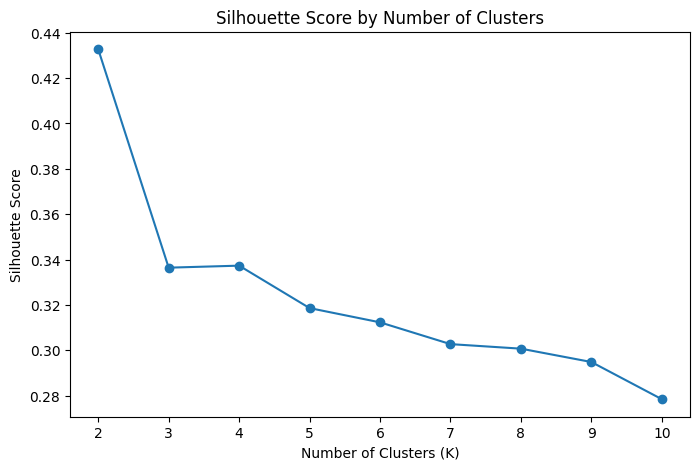

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.xticks(k_values)

plt.show()

The Silhouette Score is highest for K=2, indicating that a two-cluster solution produces the strongest separation between clusters. However, the Elbow Method suggested that approximately 4–5 clusters may provide a reasonable balance between reducing within-cluster variation and limiting model complexity.

Among the values around the elbow, K=4 has a slightly higher Silhouette Score than K=3 and K=5. A four-cluster solution was therefore selected as a candidate model, as it provides a balance between the statistical evaluation and the aim of identifying meaningful differences in customer purchasing behaviour.

The resulting clusters will be examined using the original RFM values to determine whether the four-cluster solution produces distinct and useful customer segments.

---

# Section 7 - Train and Evaluate the K-Means Model

Based on the Elbow Method and Silhouette Score analysis, a four-cluster solution was selected as the candidate model. K-Means will now be fitted using the standardised RFM features, and each customer will be assigned to a cluster.

The resulting clusters will then be examined using the original RFM values to determine whether they represent distinct patterns of customer purchasing behaviour.

In [ ]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)

cluster_labels = kmeans_final.fit_predict(rfm_scaled)

In [33]:
cluster_labels

array([3, 2, 3, ..., 0, 2, 3], shape=(4338,), dtype=int32)

In [34]:
pd.Series(cluster_labels).value_counts().sort_index()

0     836
1    1622
2     710
3    1170
Name: count, dtype: int64

In [35]:
rfm_clustered = rfm.copy()
rfm_clustered["Cluster"] = cluster_labels

In [36]:
rfm_clustered.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346,326,1,77183.60,3
1,12347,2,7,4310.00,2
2,12348,75,4,1797.24,3
3,12349,19,1,1757.55,0
4,12350,310,1,334.40,1


In [37]:
cluster_profile = rfm_clustered.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,17.642344,2.196172,557.893289
1,181.506782,1.316893,340.998626
2,12.138028,15.791549,10583.038028
3,71.479487,4.082051,1802.269438


In [38]:
cluster_median = rfm_clustered.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].median()

cluster_median

,Recency,Frequency,Monetary
Cluster,,,
0,17.0,2.0,480.110
1,174.5,1.0,296.090
2,8.0,10.0,3745.235
3,57.0,4.0,1347.250


In [ ]:
cluster_summary = (
    rfm_clustered.groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean"),
    )
    .round(2)
)

cluster_summary

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Cluster,,,,
0,836,17.64,2.20,557.89
1,1622,181.51,1.32,341.00
2,710,12.14,15.79,10583.04
3,1170,71.48,4.08,1802.27


The four clusters show clear differences in customer purchasing behaviour. Cluster 2 contains the most frequent and highest-spending customers, with purchases also occurring most recently on average. In contrast, Cluster 1 contains customers with the lowest purchase frequency and spending and the longest average time since their most recent purchase.

Clusters 0 and 3 represent different intermediate behaviours, with Cluster 0 consisting of more recent but lower-frequency customers, while Cluster 3 shows greater frequency and spending but a longer period since the most recent purchase.

The median values were also examined because the earlier analysis identified extreme customer spending values. Although the mean Monetary value for Cluster 2 is influenced by particularly high-spending customers, its median values also remain substantially higher than the other clusters, supporting the identification of this cluster as a genuinely high-value customer group.

In [ ]:
segment_names = {
    0: "Recent Low-Frequency",
    1: "Inactive Low-Value",
    2: "High-Value Frequent",
    3: "Regular",
}

In [41]:
rfm_clustered["Segment"] = rfm_clustered["Cluster"].map(segment_names)

rfm_clustered.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Regular
1,12347,2,7,4310.00,2,High-Value Frequent
2,12348,75,4,1797.24,3,Regular
3,12349,19,1,1757.55,0,Recent Low-Frequency
4,12350,310,1,334.40,1,Inactive Low-Value


In [42]:
rfm_clustered["Segment"].value_counts()

Segment
Inactive Low-Value      1622
Regular                 1170
Recent Low-Frequency     836
High-Value Frequent      710
Name: count, dtype: int64

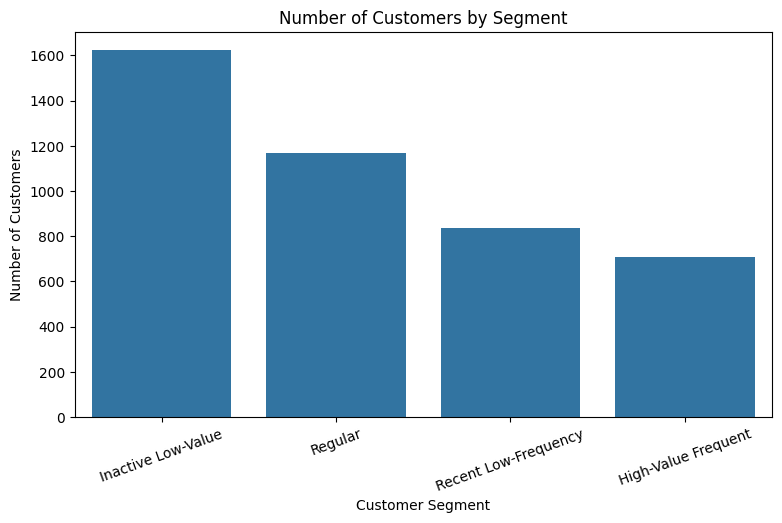

In [ ]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=rfm_clustered, x="Segment", order=rfm_clustered["Segment"].value_counts().index
)

plt.title("Number of Customers by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

The segment distribution shows that Inactive Low-Value customers form the largest group, with 1,622 customers, followed by Regular customers with 1,170. Recent Low-Frequency customers account for 836 customers, while High-Value Frequent customers form the smallest segment with 710 customers.

Although the segment sizes differ, each cluster contains a substantial number of customers, indicating that the four-cluster solution has not produced any extremely small customer groups.

### Visualise Customer Segment Profiles

The RFM characteristics of each segment will be visualised to examine how customer purchasing behaviour differs between the groups identified by K-Means.

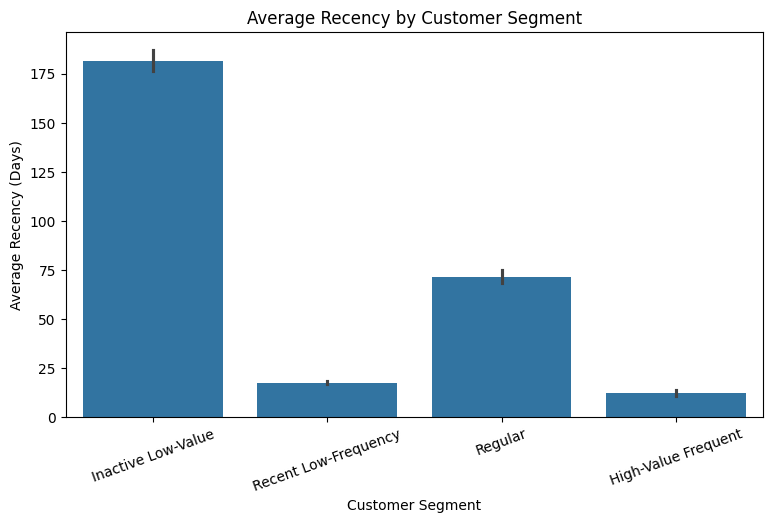

In [ ]:
segment_order = [
    "Inactive Low-Value",
    "Recent Low-Frequency",
    "Regular",
    "High-Value Frequent",
]

plt.figure(figsize=(9, 5))

sns.barplot(data=rfm_clustered, x="Segment", y="Recency", order=segment_order)

plt.title("Average Recency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Recency (Days)")
plt.xticks(rotation=20)

plt.show()

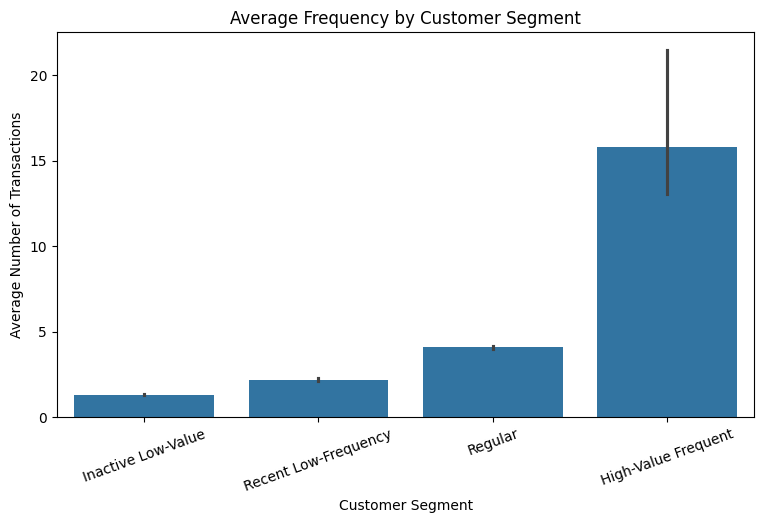

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(data=rfm_clustered, x="Segment", y="Frequency", order=segment_order)

plt.title("Average Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Number of Transactions")
plt.xticks(rotation=20)

plt.show()

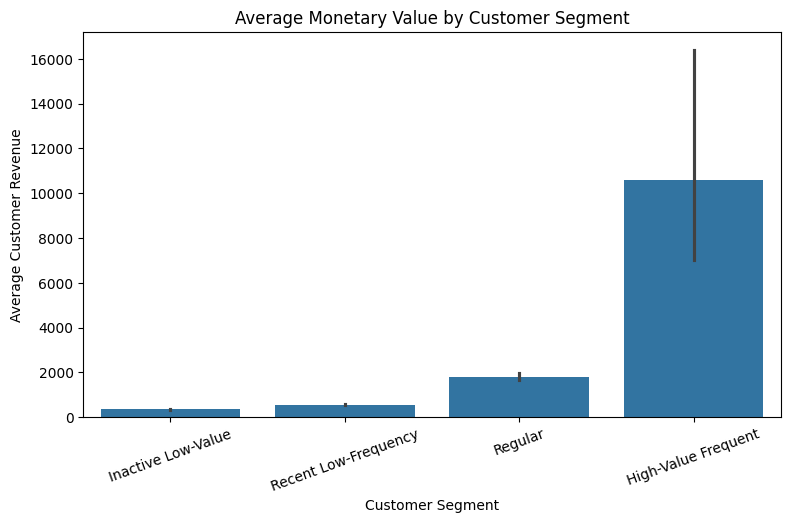

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(data=rfm_clustered, x="Segment", y="Monetary", order=segment_order)

plt.title("Average Monetary Value by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Customer Revenue")
plt.xticks(rotation=20)

plt.show()

The segment profiles show clear differences across all three RFM measures.

High-Value Frequent customers have the strongest overall purchasing behaviour. They purchased most recently on average, made substantially more transactions and generated considerably more revenue than the other segments. Although this segment contains some particularly high-spending and high-frequency customers, the earlier median analysis confirmed that the segment remains comparatively strong even when the influence of extreme values is reduced.

Recent Low-Frequency customers have purchased recently but have made relatively few transactions and generated lower revenue. This suggests recent engagement without the same level of repeat purchasing seen among the stronger customer groups.

Regular customers show moderate purchasing behaviour, with higher frequency and revenue than the Recent Low-Frequency and Inactive Low-Value segments, although their purchases are less recent.

Inactive Low-Value customers have the longest average time since their most recent purchase, alongside the lowest average transaction frequency and revenue. This distinguishes them as the least active customer segment identified by the model.

Overall, the four-cluster solution identifies distinct patterns of customer purchasing behaviour that could support more targeted customer engagement and retention strategies.

### Evaluate the Final Model

The final four-cluster K-Means model will be evaluated using the Silhouette Score. This measures how well customers fit within their assigned cluster compared with neighbouring clusters, with higher values indicating better-defined and more separated clusters.

In [47]:
final_silhouette = silhouette_score(rfm_scaled, cluster_labels)

final_silhouette

0.3373167884412268

The final four-cluster model achieved a Silhouette Score of approximately 0.337. The positive score indicates that the model has identified some meaningful cluster structure, although the customer segments are not strongly separated and some overlap between clusters is likely.

As identified during model selection, K=2 produced a higher Silhouette Score of approximately 0.433. However, the four-cluster solution was retained because the Elbow Method supported a solution around 4–5 clusters and the resulting four segments showed clear and interpretable differences across Recency, Frequency and Monetary behaviour.

The model therefore provides a useful customer segmentation for exploratory business analysis, although the moderate Silhouette Score should be considered when interpreting the clusters.

### Model Limitations

Although the K-Means model identified interpretable customer segments, several limitations should be considered when using the results.

- The final model achieved a moderate Silhouette Score, indicating that the four customer segments are not completely separated and some overlap in purchasing behaviour is likely.
- K-Means requires the number of clusters to be selected in advance. Although K=4 was supported by the Elbow Method and produced interpretable segments, K=2 achieved a higher Silhouette Score and therefore represents an alternative segmentation of the data.
- The segmentation is based only on Recency, Frequency and Monetary behaviour. Other customer characteristics that could provide additional context are not available in the dataset.
- Extreme purchasing behaviour remains present within the customer data. Log transformation reduced its influence during modelling, but some segments still contain customers with unusually high Frequency or Monetary values.
- The analysis represents customer behaviour within the historical period covered by the dataset. Customer purchasing patterns may change over time, so the resulting segments should not be treated as permanent classifications.

### Business Usefulness and Recommendations

The four customer segments could support different customer engagement strategies based on their purchasing behaviour.

- **High-Value Frequent customers:** These 710 customers are the most commercially valuable segment, averaging approximately 16 transactions and £10,583 in revenue per customer, with their most recent purchase around 12 days ago. Together, this segment generated approximately £7.51 million in total revenue, substantially more than any other customer segment. The business should therefore prioritise retaining this group through exclusive loyalty rewards, early access to new product ranges, personalised recommendations based on previous purchases, or incentives for continued repeat purchasing. Losing customers from this relatively small but highly valuable segment could have a disproportionate impact on revenue.

- **Regular customers:** These 1,170 customers average approximately 4 transactions and £1,802 in revenue per customer, but their most recent purchase was around 71 days ago. The business could focus on increasing purchase frequency through personalised product recommendations, limited-time offers based on previous purchases, or reminders designed to bring customers back sooner.

- **Recent Low-Frequency customers:** These 836 customers purchased relatively recently, around 18 days ago on average, but have only made approximately 2 transactions and generated an average of £558 in revenue per customer. As these customers are currently engaged but have not yet developed frequent purchasing behaviour, the business could target them with second or next-purchase incentives, recommendations for complementary products, or follow-up promotions shortly after a purchase to encourage repeat buying.

- **Inactive Low-Value customers:** This is the largest segment with 1,622 customers. They average only around 1 transaction and £341 in revenue per customer, with approximately 182 days since their most recent purchase. Rather than investing heavily in this lower-value group, the business could test lower-cost re-engagement approaches such as automated email campaigns or time-limited return offers. Campaign performance could then be monitored to determine whether further investment in this segment is worthwhile.

Overall, the segmentation allows the business to avoid treating all customers in the same way. Resources could be prioritised towards retaining the High-Value Frequent segment and developing Recent Low-Frequency and Regular customers, while lower-cost re-engagement methods could be tested for the Inactive Low-Value segment.

The segments should be treated as a decision-support tool rather than permanent customer classifications. Customer behaviour can change over time, so the segmentation could be recalculated periodically as new transaction data becomes available.

---

# Section 8 - Export Customer Segmentation Results

The final customer segmentation results will be exported so that the identified customer segments can be used for further analysis, reporting or business decision-making.

The exported dataset contains each customer's RFM values, assigned K-Means cluster and corresponding customer segment.

In [48]:
rfm_clustered.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Regular
1,12347,2,7,4310.00,2,High-Value Frequent
2,12348,75,4,1797.24,3,Regular
3,12349,19,1,1757.55,0,Recent Low-Frequency
4,12350,310,1,334.40,1,Inactive Low-Value


In [50]:
rfm_clustered.to_csv("outputs/customer_segmentation_results.csv", index=False)

In [51]:
os.path.exists("outputs/customer_segmentation_results.csv")

True

The customer segmentation results were successfully exported to `outputs/customer_segmentation_results.csv`. The exported dataset contains 4,338 customer records with their RFM values, assigned cluster and corresponding customer segment.

This output can be used for further analysis, reporting or to support targeted customer strategies based on the identified purchasing behaviours.